In [ ]:
# !rm -rf /content/drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import glob
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
import seaborn as sns


In [ ]:
files = glob.glob("/content/drive/MyDrive/price_forecasting/**/*.csv", recursive=True)
for f in files:
    print(f)

/content/drive/MyDrive/price_forecasting/data/hb_houston_hourly_2018_2023.csv
/content/drive/MyDrive/price_forecasting/data/rpt.00013061.0000000000000000.20190101.082527062.RTMLZHBSPP_2018/rpt.00013061.0000000000000000.RTMLZHBSPP_2018.csv
/content/drive/MyDrive/price_forecasting/data/rpt.00013061.0000000000000000.20240101.081911295.RTMLZHBSPP_2023/rpt.00013061.0000000000000000.RTMLZHBSPP_2023.csv
/content/drive/MyDrive/price_forecasting/data/rpt.00013061.0000000000000000.20210101.084127415.RTMLZHBSPP_2020/rpt.00013061.0000000000000000.RTMLZHBSPP_2020.csv
/content/drive/MyDrive/price_forecasting/data/rpt.00013061.0000000000000000.20200101.082516926.RTMLZHBSPP_2019/rpt.00013061.0000000000000000.RTMLZHBSPP_2019.csv
/content/drive/MyDrive/price_forecasting/data/rpt.00013061.0000000000000000.20220101.083820464.RTMLZHBSPP_2021/rpt.00013061.0000000000000000.RTMLZHBSPP_2021.csv
/content/drive/MyDrive/price_forecasting/data/rpt.00013061.0000000000000000.20230101.083407763.RTMLZHBSPP_2022/rpt.00

In [ ]:
DATA_DIR = "/content/drive/MyDrive/price_forecasting/data"
RESULTS_DIR = "/content/drive/MyDrive/price_forecasting/results"
os.makedirs(RESULTS_DIR, exist_ok=True)

FINAL_PATH = f"{DATA_DIR}/hb_houston_hourly_2018_2023.csv"
df = pd.read_csv(FINAL_PATH, parse_dates=["timestamp"]).sort_values("timestamp")
df = df.set_index("timestamp")
df.head(), df.shape

(                       price
 timestamp                   
 2018-01-01 00:00:00  27.5700
 2018-01-01 01:00:00  27.6975
 2018-01-01 02:00:00  27.5350
 2018-01-01 03:00:00  27.9650
 2018-01-01 04:00:00  28.6375,
 (52584, 1))

In [ ]:
# for plotting purposes
# df["z_diff1"] = df["z"].diff(1)
# df["z_diff24"] = df["z"].diff(24)


# # split
# train = df.loc["2018-01-01":"2021-12-31 23:00:00"].copy()
# val = df.loc["2022-01-01":"2022-12-31 23:00:00"].copy()
# test = df.loc["2023-01-01":"2023-12-31 23:00:00"].copy()

# data transformation
df["price"] = df["price"].ffill()
print(df.shape)
df["z"] = np.arcsinh(df["price"])
# graphing
df["z_diff1"] = df["z"].diff(1)
df["z_diff24"] = df["z"].diff(24)
#
df["z_diff1&24"] = df["z"].diff(1).diff(24)
df = df.dropna(subset=["z_diff1&24"])

# mini split
# train = df.loc["2018-01-01":"2018-12-31 23:00:00"].copy()
# val = df.loc["2019-01-01":"2019-12-31 23:00:00"].copy()
# test = df.loc["2020-01-01":"2020-12-31 23:00:00"].copy()

# split
train = df.loc["2020-01-01":"2021-12-31 23:00:00"].copy()
val = df.loc["2022-01-01":"2022-12-31 23:00:00"].copy()
test = df.loc["2023-01-01":"2023-12-31 23:00:00"].copy()

(52484, 5)


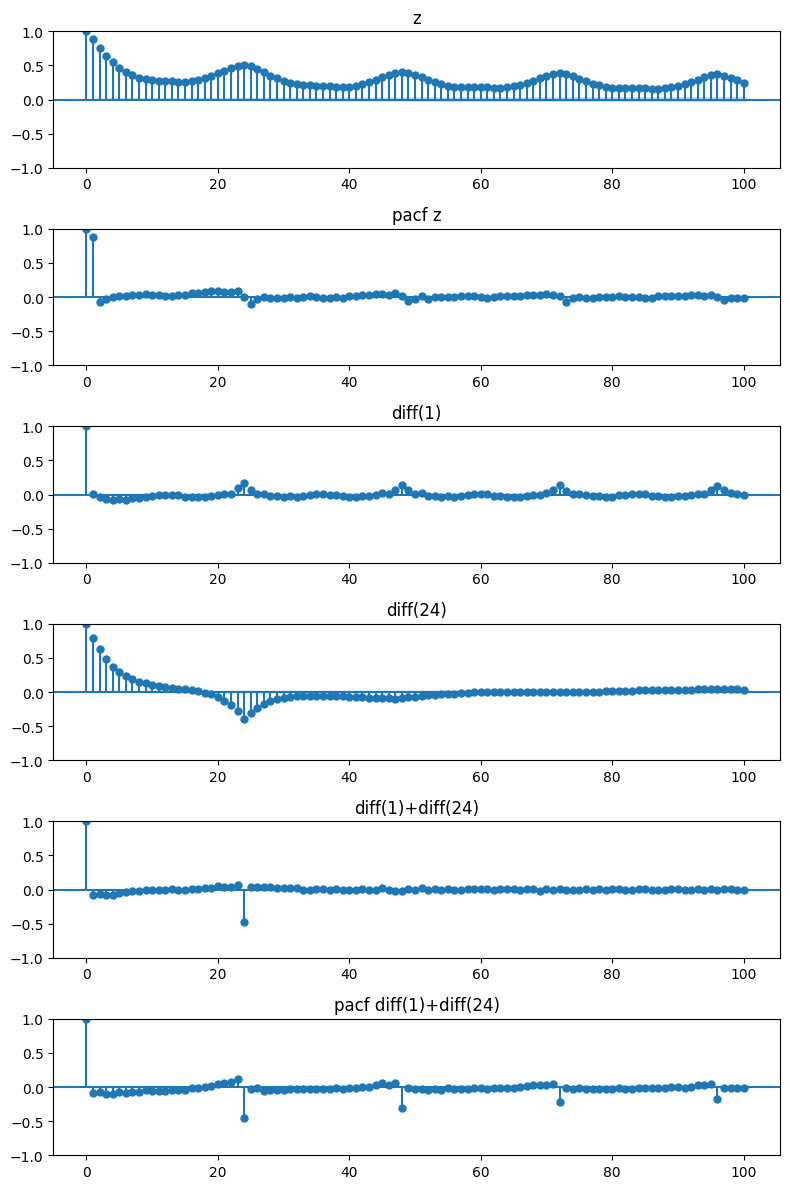

In [ ]:
fig, axes = plt.subplots(6, 1, figsize=(8, 12))

plot_acf(df["z"].dropna(), lags=100, ax=axes[0])
axes[0].set_title("z")

plot_pacf(df["z"].dropna(), lags=100, ax=axes[1])
axes[1].set_title("pacf z")

plot_acf(df["z_diff1"].dropna(), lags=100, ax=axes[2])
axes[2].set_title("diff(1)")

plot_acf(df["z_diff24"].dropna(), lags=100, ax=axes[3])
axes[3].set_title("diff(24)")

plot_acf(df["z_diff1&24"].dropna(), lags=100, ax=axes[4])
axes[4].set_title("diff(1)+diff(24)")

plot_pacf(df["z_diff1&24"].dropna(), lags=100, ax=axes[5])
axes[5].set_title("pacf diff(1)+diff(24)")



plt.tight_layout()
plt.show()

In [ ]:
# loss function
def mae(y, yhat):
    y = np.asarray(y).ravel()
    yhat = np.asarray(yhat).ravel()
    return float(np.mean(np.abs(y - yhat)))

def rmse(y, yhat):
    y = np.asarray(y).ravel()
    yhat = np.asarray(yhat).ravel()
    return float(np.sqrt(np.mean((y - yhat) ** 2)))

def eval_metrics_spike(y_train, y, yhat, q=0.95, name="model"):
    y_train = np.asarray(y_train).ravel()
    y = np.asarray(y).ravel()
    yhat = np.asarray(yhat).ravel()

    assert len(y) == len(yhat)

    # threshold learned from training set only
    train_magnitude = np.abs(y_train)
    threshold = np.quantile(train_magnitude, q)

    # masks built on evaluation target y
    eval_magnitude = np.abs(y)
    normal_mask = eval_magnitude <= threshold
    spike_mask  = eval_magnitude > threshold

    mae_normal  = mae(y[normal_mask], yhat[normal_mask])
    rmse_normal = rmse(y[normal_mask], yhat[normal_mask])
    mae_spike   = mae(y[spike_mask],  yhat[spike_mask])
    rmse_spike  = rmse(y[spike_mask], yhat[spike_mask])

    return {
        "model": name,
        "threshold": float(threshold),

        "normal_count": int(normal_mask.sum()),
        "normal_MAE": mae_normal,
        "normal_RMSE": rmse_normal,

        "spike_count": int(spike_mask.sum()),
        "spike_MAE": mae_spike,
        "spike_RMSE": rmse_spike
    }

In [ ]:
def read_metrics(d):
    '''
    input: dictionary of mae, rmse metrics
    output: formatted string
    '''
    s = (
        f"Model: {d['model']}\n"
        f"Threshold: {d['threshold']:.4f}\n\n"

        f"Normal regime (|y| <= threshold)\n"
        f"Count: {d['normal_count']}\n"
        f"MAE : {d['normal_MAE']:.4f}\n"
        f"RMSE: {d['normal_RMSE']:.4f}\n\n"

        f"Spike regime (|y| > threshold)\n"
        f"Count: {d['spike_count']}\n"
        f"MAE : {d['spike_MAE']:.4f}\n"
        f"RMSE: {d['spike_RMSE']:.4f}"
    )

    return s

In [ ]:
def arima_walk_forward_forecast(history, target, order, refit_every):
    history = list(np.asarray(history, dtype=float))
    target = np.asarray(target, dtype=float).ravel()

    preds = np.zeros(len(target), dtype=float)
    model_fit = None

    for i in range(len(target)):
        # Refit periodically on the full expanded history
        if (i == 0) or (refit_every > 0 and i % refit_every == 0):
            model = ARIMA(
                history,
                order=order,
                enforce_stationarity=False,
                enforce_invertibility=False
            )
            print(f'refitting\n')
            model_fit = model.fit(method_kwargs={"maxiter": 50})

        if i % 1000 == 0:
            print("step", i)

        # 1-step-ahead forecast from current state
        preds[i] = model_fit.forecast(steps=1)[0]

        # Update internal state with the true observed value
        model_fit = model_fit.append([target[i]], refit=False)

        # Keep external history in sync for next periodic refit
        history.append(target[i])

    return preds

In [ ]:
order_z = (0, 0, 1)

y_train = train["z_diff1&24"].to_numpy()
y_val   = val["z_diff1&24"].to_numpy()
y_test  = test["z_diff1&24"].to_numpy()

# walk-forward predictions
print(f'test run')
zhat_val = arima_walk_forward_forecast(
    y_train,
    y_val,
    order_z,
    refit_every=24*90
)

print(f'validation run')
zhat_test = arima_walk_forward_forecast(
    np.concatenate([y_train, y_val]),
    y_test,
    order_z,
    refit_every=24*90
)

test run
refitting

step 0
step 1000
step 2000
refitting

step 3000
step 4000
refitting

step 5000
step 6000
refitting

step 7000
step 8000
refitting

validation run
refitting

step 0
step 1000
step 2000
refitting

step 3000
step 4000
refitting

step 5000
step 6000
refitting

step 7000
step 8000
refitting



In [ ]:
y_train_2 = np.concatenate([y_train, y_val])
train_result = eval_metrics_spike(y_train, y_val,  zhat_val,  name=f"ARIMA{order_z} on z_diff1&24 (val)")
val_result = eval_metrics_spike(y_train_2, y_test, zhat_test, name=f"ARIMA{order_z} on z_diff1&24 (test)")
print(read_metrics(train_result))
print(read_metrics(val_result))

Model: ARIMA(0, 0, 1) on z_diff1&24 (val)
Threshold: 1.2698

Normal regime (|y| <= threshold)
Count: 8418
MAE : 0.2129
RMSE: 0.3259

Spike regime (|y| > threshold)
Count: 342
MAE : 2.1738
RMSE: 2.4160
Model: ARIMA(0, 0, 1) on z_diff1&24 (test)
Threshold: 1.2154

Normal regime (|y| <= threshold)
Count: 8244
MAE : 0.2461
RMSE: 0.3569

Spike regime (|y| > threshold)
Count: 516
MAE : 2.2575
RMSE: 2.5963


In [ ]:
def plot_forecast_window(y, yhat, index=None, start=0, window=24*7, title="Forecast vs Actual"):
    y = np.asarray(y).ravel()
    yhat = np.asarray(yhat).ravel()
    assert len(y) == len(yhat), "y and yhat must have same length"

    end = min(start + window, len(y))

    if index is None:
        x = np.arange(start, end)
    else:
        x = index[start:end]

    plt.figure(figsize=(12, 4))
    plt.plot(x, y[start:end], label="Actual")
    plt.plot(x, yhat[start:end], label="Predicted")
    plt.title(title)
    plt.xlabel("Time")
    plt.ylabel("Target")
    plt.legend()
    plt.tight_layout()
    plt.show()

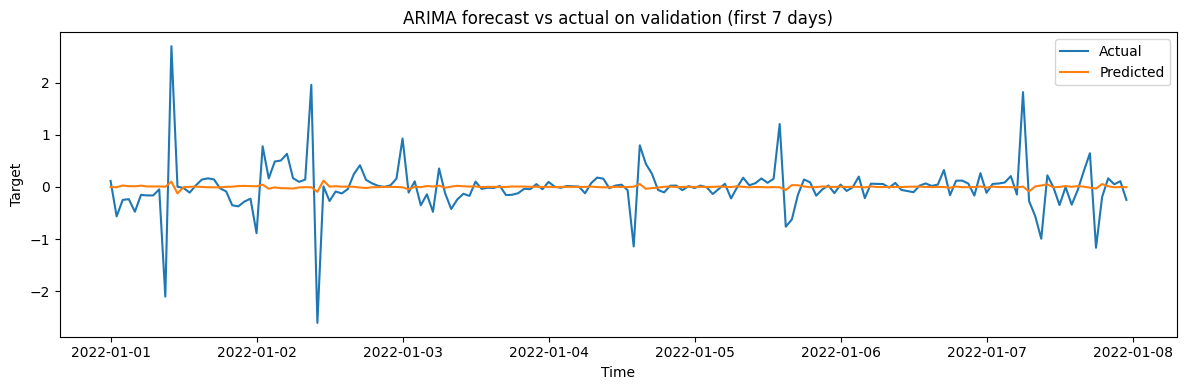

In [ ]:
plot_forecast_window(
    y_val,
    zhat_val,
    index=val.index,
    start=0,
    window=24*7,
    title="ARIMA forecast vs actual on validation (first 7 days)"
)

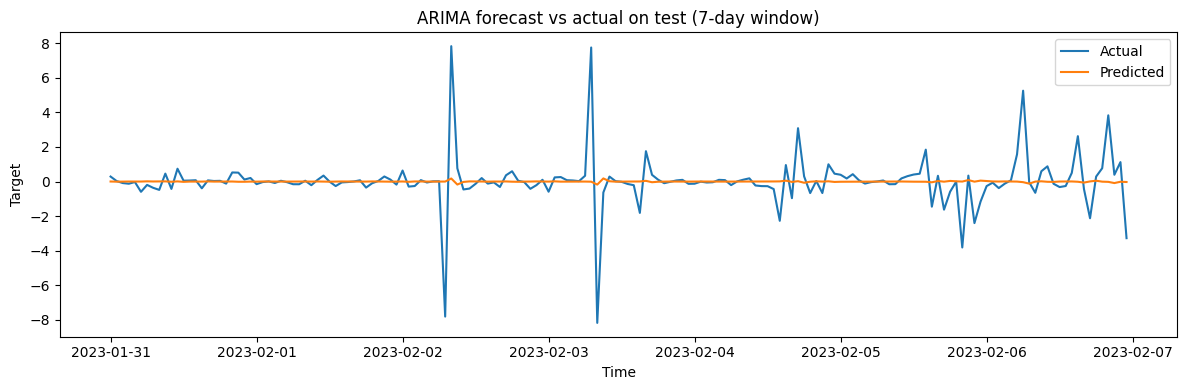

In [ ]:
plot_forecast_window(
    y_test,
    zhat_test,
    index=test.index,
    start=24*30,
    window=24*7,
    title="ARIMA forecast vs actual on test (7-day window)"
)

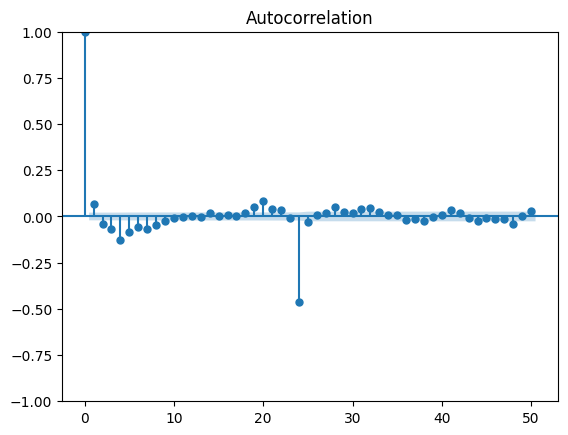

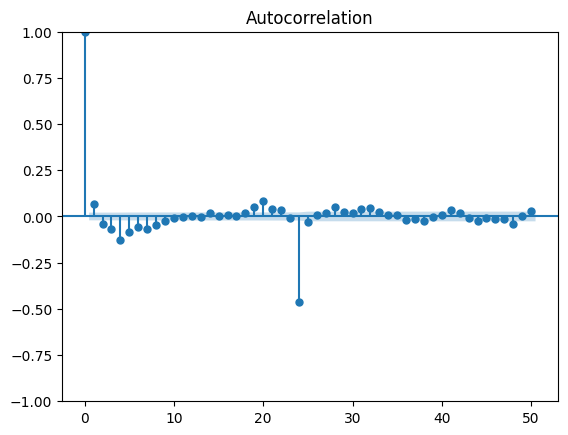

In [ ]:
residuals = y_val - zhat_val

plot_acf(residuals, lags=50)

<Axes: ylabel='Count'>

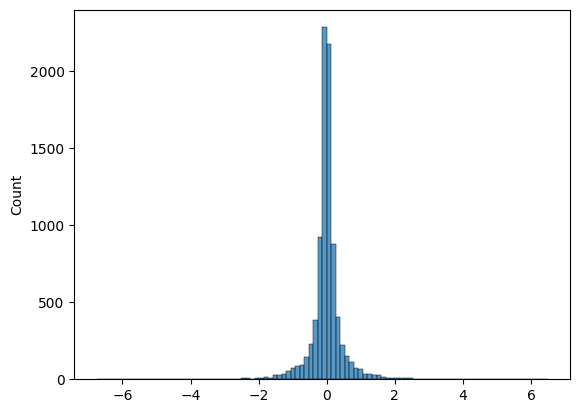

In [ ]:
sns.histplot(residuals, bins=100)

In [ ]:
# !jupyter nbconvert --to python "/content/drive/MyDrive/price_forecasting/notebooks/03_price_only_baseline_arima.ipynb"

[NbConvertApp] Converting notebook /content/drive/MyDrive/price_forecasting/notebooks/03_price_only_baseline_arima.ipynb to python
[NbConvertApp] Writing 7701 bytes to /content/drive/MyDrive/price_forecasting/notebooks/03_price_only_baseline_arima.py


In [ ]:
# !mv "/content/drive/MyDrive/price_forecasting/notebooks/03_price_only_baseline_arima.py" \
#     "/content/drive/MyDrive/price_forecasting/notebooks/arima_baseline.py"